# Car Detection and Tracking

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ziadelh/traffic-car-tracking/blob/main/car_detection_tracking.ipynb)

Detects and tracks moving cars on the main street in a recording from a traffic camera in Laramie, Wyoming, using classical computer vision only (no machine learning):

- **Frame differencing** finds pixels that changed since the previous frame.
- **Background subtraction** (OpenCV's MOG2) finds pixels that do not belong to the learned background.
- The two masks are combined, cleaned with morphology, and the blobs are filtered by size, shape, edge density and contrast to keep the ones that look like cars.
- A **Kalman filter** per car predicts where it will be next, and detections are matched to tracks by overlap and distance, so every car keeps one ID.

The output is the video with a green box and an ID on every tracked car.

## Setup

In [1]:
import os, urllib.request

# The traffic recordings are large, so they are published as a release asset instead of being stored in the repository
BASE_URL = "https://github.com/ziadelh/traffic-car-tracking/releases/download/data-v1/"
for name in ['Traffic_Laramie_1.mp4']:
    if not os.path.exists(name):
        print("Downloading", name, "...")
        urllib.request.urlretrieve(BASE_URL + name, name)
print("Videos ready.")

Videos ready.


## **Cell 1  Imports**

In [2]:
# imports
import cv2 as cv, numpy as np
from math import hypot
from pathlib import Path
import time

## **Cell 2  Paths**

In [3]:
# Paths and setup
ROOT = Path(".").resolve()
VID = ROOT / "Traffic_Laramie_1.mp4"
OUT = ROOT / "exercise1_out"; OUT.mkdir(exist_ok=True)
assert VID.exists(), f"Video not found: {VID}"
print("OK")


OK


## **Cell 3  ROI Setup**

Read first frame, define the road ROI band, and save a preview image.


In [4]:
# Read first frame
cap = cv.VideoCapture(str(VID))
ok, frame0 = cap.read(); cap.release()
assert ok, "Could not read first frame."
h, w = frame0.shape[:2]

# ROI 
y_top  = int(0.58 * h)
y_bot  = int(0.985 * h)

roi_poly = np.array([[(0, y_top), (w-1, y_top), (w-1, y_bot), (0, y_bot)]], dtype=np.int32)
roi_mask = np.zeros((h, w), dtype=np.uint8); cv.fillPoly(roi_mask, roi_poly, 255)

# ROI preview
overlay = frame0.copy()
cv.polylines(overlay, roi_poly, True, (0,0,255), 2)
preview = cv.addWeighted(overlay, 1.0, cv.cvtColor(roi_mask, cv.COLOR_GRAY2BGR), 0.25, 0)

pv = OUT / "roi_preview.jpg"
cv.imwrite(str(pv), preview)
print("ROI preview saved | frame:", (w, h))


ROI preview saved | frame: (1040, 600)


## **Cell 4  Helper Functions**

Utility functions for box overlap IoU and for clipping boxes to frame bounds.


In [5]:
def iou_xywh(a, b):
    # Intersection over Union for two boxes
    ax, ay, aw, ah = a; bx, by, bw, bh = b
    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh
    ix1, iy1 = max(ax, bx), max(ay, by)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    union = aw * ah + bw * bh - inter + 1e-6
    return inter / union

def clip_box(box, W, H):
    # Clip a box to stay inside frame size
    x, y, w, h = map(int, box)
    x = max(0, min(x, W-1))
    y = max(0, min(y, H-1))
    w = max(1, min(w, W-x))
    h = max(1, min(h, H-y))
    return (x, y, w, h)


## **Cell 5  Car Detection**

Detect moving cars in the ROI using frame differencing, background subtraction, and simple filters.


In [6]:
def detect_working_cars(band, prev_band, fgbg):
    # Detect cars using motion and background subtraction with filters.
    h, w = band.shape[:2]
    gray = cv.cvtColor(band, cv.COLOR_BGR2GRAY)
    prev_gray = cv.cvtColor(prev_band, cv.COLOR_BGR2GRAY) if prev_band is not None else gray

    # frame differencing
    if prev_band is not None:
        diff = cv.absdiff(gray, prev_gray)
        _, motion = cv.threshold(diff, 20, 255, cv.THRESH_BINARY)
    else:
        motion = np.zeros((h, w), dtype=np.uint8)

    # Background subtraction
    raw = fgbg.apply(band, learningRate=0.0)
    fg = (raw == 255).astype(np.uint8) * 255

    # Combine and clean
    combined = cv.bitwise_or(motion, fg)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3))
    cleaned = cv.morphologyEx(combined, cv.MORPH_CLOSE, kernel)
    cleaned = cv.morphologyEx(cleaned, cv.MORPH_OPEN,  kernel)

    # Contour analysis
    contours, _ = cv.findContours(cleaned, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    car_boxes = []

    for contour in contours:
        x, y, w_rect, h_rect = cv.boundingRect(contour)

        if w_rect < 30 or h_rect < 20: continue
        if w_rect > 300 or h_rect > 200: continue

        # Aspect ratio
        aspect_ratio = w_rect / float(h_rect)
        if aspect_ratio < 1.0 or aspect_ratio > 6.0: continue

        # Area filter
        area = w_rect * h_rect
        if area < 600 or area > 40000: continue

        contour_area = cv.contourArea(contour)
        if contour_area < 400: continue
        rect_area = w_rect * h_rect
        if contour_area / rect_area < 0.25: continue

        # Edge density
        roi = gray[y:y+h_rect, x:x+w_rect]
        if roi.size == 0: continue
        edges = cv.Canny(roi, 50, 150)
        edge_density = np.sum(edges > 0) / float(roi.size)
        if edge_density < 0.02 or edge_density > 0.6: continue

        color_std = np.std(roi)
        if color_std < 10 or color_std > 100: continue

        car_boxes.append((x, y, w_rect, h_rect))

    return car_boxes


## **Cell 6  Tracking Class**

Defines a car track with Kalman filter, prediction, and correction steps.


In [7]:
class WorkingCarTrack:
    def __init__(self, box, frame, track_id):
        # Initialize a track with a Kalman filter and box size.
        H, W = frame.shape[:2]
        x, y, w, h = clip_box(box, W, H)
        cx, cy = x + w/2.0, y + h/2.0

        self.track_id = track_id
        # Kalman filter
        self.kf = cv.KalmanFilter(4, 2)
        dt = 1.0
        self.kf.transitionMatrix = np.array([[1,0,dt,0],
                                             [0,1,0,dt],
                                             [0,0,1,0],
                                             [0,0,0,1]], np.float32)
        self.kf.measurementMatrix = np.array([[1,0,0,0],
                                              [0,1,0,0]], np.float32)
        self.kf.processNoiseCov = np.diag([2e-2,2e-2,6e-2,6e-2]).astype(np.float32)
        self.kf.measurementNoiseCov = np.diag([0.8,0.8]).astype(np.float32)
        self.kf.errorCovPost = np.eye(4, dtype=np.float32)
        self.kf.statePost = np.array([[cx],[cy],[0.0],[0.0]], np.float32)

        self.size = np.array([w,h], np.float32)
        self.box = (x,y,w,h)
        self.hits = 1
        self.miss = 0
        self.consecutive_misses = 0
        self.W, self.H = W, H
        self.smooth_alpha = 0.88
        self.in_roi = True

    def speed(self):
        # Return current speed magnitude
        vx = float(self.kf.statePost[2,0])
        vy = float(self.kf.statePost[3,0])
        return (vx*vx + vy*vy)**0.5

    def predict(self):
        # Predict next box position.
        p = self.kf.predict()
        if self.miss > 0:
            self.kf.statePost[2:4] *= 0.85
            p = self.kf.statePost.copy()

        cx = float(p[0,0]); cy = float(p[1,0])
        self.in_roi = (y_top <= cy <= y_bot)

        x = int(round(cx - self.size[0]/2.0))
        y = int(round(cy - self.size[1]/2.0))
        self.box = clip_box((x,y,int(self.size[0]),int(self.size[1])), self.W, self.H)
        return self.box

    def correct(self, det, frame):
        # Correct prediction
        H, W = frame.shape[:2]
        x, y, w, h = clip_box(det, W, H)
        cxm, cym = x + w/2.0, y + h/2.0

        meas = np.array([w,h], np.float32)
        meas = np.clip(meas, self.size*0.8, self.size*1.2)
        self.size = 0.9*self.size + 0.1*meas

        self.kf.correct(np.array([[cxm],[cym]], np.float32))
        p = self.kf.statePost
        cxp, cyp = float(p[0,0]), float(p[1,0])

        # Smoothed position
        cx = self.smooth_alpha*cxm + (1-self.smooth_alpha)*cxp
        cy = self.smooth_alpha*cym + (1-self.smooth_alpha)*cyp

        x = int(round(cx - self.size[0]/2.0))
        y = int(round(cy - self.size[1]/2.0))
        self.box = clip_box((x,y,int(self.size[0]),int(self.size[1])), W, H)
        self.hits += 1
        self.miss = 0
        self.consecutive_misses = 0
        return self.box


## **Cell 7  Track Manager**

Manages multiple car tracks prediction, matching with detections, removing lost tracks, and creating new ones.


In [8]:
class WorkingCarManager:
    def __init__(self, y0, y1, W):
        # Handling multiple car tracks.
        self.y0, self.y1 = y0, y1
        self.W = W
        self.left_x = int(0.16 * W)
        self.right_x = int(0.84 * W)
        self.anti_birth_radius = 90
        self.max_miss = 18
        self.max_miss_stationary = 30
        self.tracks = {}
        self.next_id = 0
        self.frame_count = 0

    def _center(self, b):
        # Return box center.
        x, y, w, h = b
        return (x + 0.5 * w, y + 0.5 * h)

    def _in_entry(self, box):
        # Check if box is near entry region
        x, y, w, h = box
        cx = x + w / 2.0
        return (cx < self.left_x) or (cx > self.right_x)

    def _too_near_live(self, det):
        # Check if detection is too close to an active track.
        dc = self._center(det)
        for t in self.tracks.values():
            pc = self._center(t.box)
            if hypot(dc[0]-pc[0], dc[1]-pc[1]) < self.anti_birth_radius:
                return True
            if iou_xywh(det, t.box) > 0.18:
                return True
        return False

    def update(self, frame, detections):
        # Update tracks with new detections.
        self.frame_count += 1

        tids = list(self.tracks.keys())
        preds = {}
        for tid in tids:
            b = self.tracks[tid].predict()
            preds[tid] = b
            if not self.tracks[tid].in_roi:
                self.tracks.pop(tid, None)

        tids = list(self.tracks.keys())
        matches = []
        U_t = set(tids)
        U_d = set(range(len(detections)))

        # Match detections 
        if tids and detections:
            C = np.full((len(tids), len(detections)), 1e3, np.float32)
            for i, tid in enumerate(tids):
                pb = preds[tid]
                for j, db in enumerate(detections):
                    iou = iou_xywh(pb, db)
                    if iou < 0.08: 
                        continue
                    pc = self._center(pb)
                    dc = self._center(db)
                    spatial_dist = hypot(pc[0]-dc[0], pc[1]-dc[1]) / 100.0
                    C[i, j] = (1.0 - iou) + 0.15 * spatial_dist

            for _ in range(min(len(tids), len(detections))):
                i, j = divmod(np.argmin(C), C.shape[1])
                if C[i, j] >= 0.92: break
                matches.append((tids[i], j))
                C[i, :] = 1e3
                C[:, j] = 1e3
                U_t.discard(tids[i])
                U_d.discard(j)

        for tid, j in matches:
            self.tracks[tid].correct(detections[j], frame)

        # Handle unmatched tracks
        for tid in list(U_t):
            t = self.tracks[tid]
            t.miss += 1
            t.consecutive_misses += 1
            if t.consecutive_misses > 10:
                self.tracks.pop(tid, None)
                continue
            limit = self.max_miss_stationary if t.speed() < 0.3 else self.max_miss
            if t.miss > limit:
                self.tracks.pop(tid, None)

        # Create new tracks
        for j in list(U_d):
            det = detections[j]
            if not self._in_entry(det): continue
            if self._too_near_live(det): continue
            self.tracks[self.next_id] = WorkingCarTrack(det, frame, self.next_id)
            self.next_id += 1

    def visible(self):
        return {tid: t.box for tid, t in self.tracks.items() if t.miss <= 10}


## **Cell 8  Initialization**

Open the video, set parameters, create background subtractor, track manager, and video writer.


In [9]:
# Open video and get properties
cap = cv.VideoCapture(str(VID))
fps = cap.get(cv.CAP_PROP_FPS) or 25.0
W, H = int(cap.get(cv.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
y0, y1 = y_top, y_bot

# Background subtractor
fgbg = cv.createBackgroundSubtractorMOG2(history=150, varThreshold=18, detectShadows=False)

# Track manager
TM = WorkingCarManager(y0, y1, W)

# Video writer
out_path = OUT / "task1_WORKING_CAR_DETECTION_FIXED.mp4"
writer = cv.VideoWriter(str(out_path), cv.VideoWriter_fourcc(*"mp4v"), fps, (W, H))

print("Starting WORKING CAR DETECTION system...")
start_time = time.time()
prev_band = None


Starting WORKING CAR DETECTION system...


## **Cell 9  Main Loop**

Process each frame


In [10]:
while True:
    ok, frame = cap.read()
    if not ok:
        break

    # Extract ROI 
    band = frame[y0:y1]
    car_boxes = detect_working_cars(band, prev_band, fgbg)
    prev_band = band.copy()

    dets = [(x, y+y0, w, h) for (x,y,w,h) in car_boxes]
    TM.update(frame, dets)

    # Visualization
    vis = frame.copy()
    cv.polylines(vis, roi_poly, True, (0,0,255), 2)

    # Show detection count
    cv.putText(vis, f"Detections: {len(dets)}", (10, 30),
               cv.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)

    # boxes for active tracks
    for tid, (x,y,w,h) in TM.visible().items():
        if y+h <= y0 or y >= y1:
            continue
        cv.rectangle(vis, (x,y), (x+w,y+h), (0,255,0), 2)
        cv.putText(vis, f"ID {tid}", (x, max(0,y-6)),
                   cv.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    # output video
    writer.write(vis)


In [11]:
cap.release(); writer.release()

end_time = time.time()
processing_time = end_time - start_time
print(f"Tracks created: {TM.next_id}")
print(f"Video saved to: {out_path.relative_to(ROOT)}")

Tracks created: 34
Video saved to: exercise1_out\task1_WORKING_CAR_DETECTION_FIXED.mp4


## Result

Four frames from the output video.

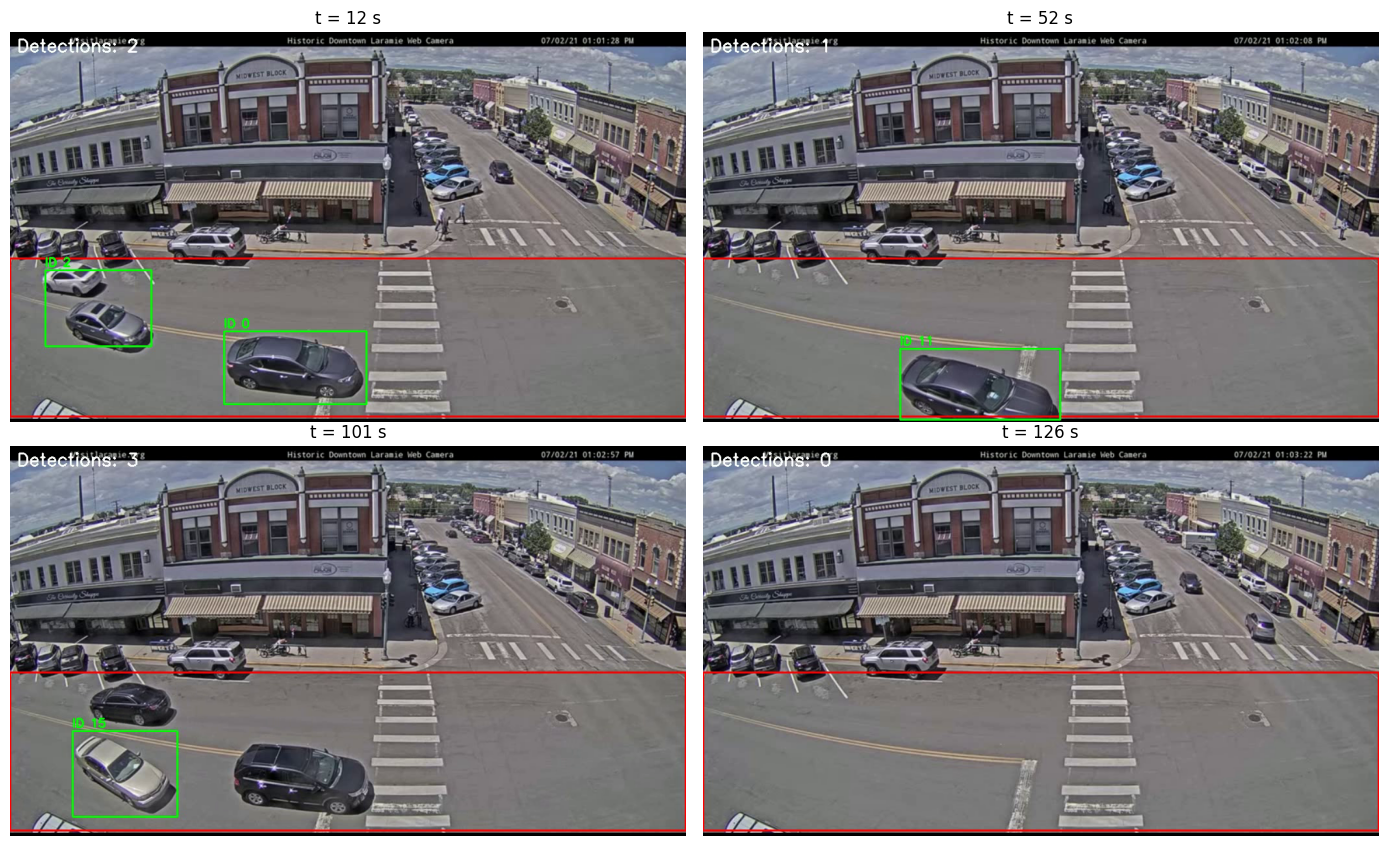

In [12]:
import matplotlib.pyplot as plt

cap = cv.VideoCapture(str(out_path))
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
for ax, t in zip(axes.ravel(), [12, 52, 101, 126]):
    cap.set(cv.CAP_PROP_POS_FRAMES, int(t * fps))
    ok, frame = cap.read()
    ax.imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
    ax.set_title(f"t = {t} s")
    ax.axis("off")
cap.release()
plt.tight_layout()
plt.show()